In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time # can convert date to JD
import astro_models  # with pip install batman-package
from astropy import constants as c
import math

import pandas as pd

### Required functions

In [4]:
def convert_date(input_date):
    from datetime import datetime

    # Parse the input date string into a datetime object
    datetime_obj = datetime.strptime(input_date, "%m/%d/%Y %H:%M")

    # Convert the datetime object to the desired format
    formatted_date = datetime_obj.strftime("%Y-%m-%dT%H:%M:00.")

    return formatted_date

def format_date_column(input_frame):

    # input: the data of column of interest in the format of dataframe[''] 
    # -> convert the panda dataframe into a list using tolist() 
    # -> convert the number in the list into a list of strings using list(map(str,number_list)) 
    # instead of list comprehension: strings_list = [str(number) for number in numbers]

    format_column = list(map(str,input_frame.tolist()))

    # change the list of strings of date into a correct format using the function created before
    converted_date = [convert_date(date) for date in format_column]
    
    return converted_date

# ---------------------------------- Lisa --------------------------------------------------------------------------------------
def plot_windows(midt, startt, endt, airmass_pre, goodness, ncols=3):
    fig, ax = plt.subplots(ncols=ncols, nrows= math.ceil(len(airmass_pre)/ncols), figsize=(10,20), sharey=True)
    for i in range(len(airmass_pre)):
        col, row = int(i/ncols), i%ncols
        ax[col,row].axvline(startt.jd[i], lw=3, c='grey')
        ax[col,row].axvline(endt.jd[i], lw=3, c='grey')
        ax[col,row].axvspan(startt.jd[i], endt.jd[i], alpha=0.2, color='grey')
        if goodness[i]==True:
            ax[col,row].axvspan(midt.jd[i]-2.5/24, midt.jd[i]+2.5/24, alpha=0.2, color='green') # 2.5 before & after the 0.6 phase.
        else:
            ax[col,row].axvspan(midt.jd[i]-2.5/24, midt.jd[i]+2.5/24, alpha=0.1, color='red')
        ax[col,row].axvline(midt.jd[i], lw=3, c='red', ls='--')
        title = midtimes[i]+', airmass:'+str(airmass_pre[i])
        ax[col,row].set_title(title, fontsize=8)
    fig.subplots_adjust(wspace=0.1, hspace=0.5)
    return 

#### Convert to Julian date Example

In [5]:
# Test the function with the provided input_date
input_date = "04/11/2023 10:03"
format_date = convert_date(input_date)

# Create an Astropy Time object with the input date and specify the input format
time_object = Time(format_date, format='isot', scale='utc')

# Convert to Julian Date
julian_date = time_object.jd

print(f"Input Date: {input_date}")
print(f"Formatted Date: {format_date}")
print(f"Julian Date: {julian_date}")

Input Date: 04/11/2023 10:03
Formatted Date: 2023-04-11T10:03:00.
Julian Date: 2460045.91875


#### Extract observation window of time

##### Post-eclipse for fast turnaround proposal

In [10]:
# Read the csv file using pandas: SORTED TABLE IN INCREASING AIRMASS (not date)
# file_path = 'transits_airmass_order.csv' # export the transits table to csv, delete the first 35 irrelevant columns
# file_path = 'transit_0.6_am_ascend.csv'
# file_path = 'transit_0.62_am_asc.csv'
file_path = 'transits_0.58_am_asc.csv'
dataframe = pd.read_csv(file_path) 

# print(dataframe)

starttimes = format_date_column(dataframe['targetobsstartcalendar'])
midtimes = format_date_column(dataframe['midpointcalendar'])
endtimes = format_date_column(dataframe['targetobsendcalendar'])

airmass_post = list(map(str,dataframe['midpointairmass'].tolist()))
phase = dataframe['phase'][0]

print('Phase is', phase)
print(f"Start times: {starttimes}")
print(f"Mid times: {midtimes}")
print(f"End times: {endtimes}")
print(f"Airmass in increasing order: {airmass_post}")


Phase is 0.58
Start times: ['2023-10-02T23:37:00.', '2023-09-25T23:33:00.', '2023-09-18T23:29:00.', '2023-09-11T23:25:00.', '2023-09-04T23:22:00.', '2023-08-28T23:18:00.', '2023-08-21T23:15:00.', '2023-08-14T23:12:00.', '2023-08-07T23:08:00.', '2023-07-31T23:06:00.', '2023-08-02T23:05:00.', '2023-08-09T23:08:00.']
Mid times: ['2023-10-03T00:19:00.', '2023-09-26T00:59:00.', '2023-09-19T01:40:00.', '2023-09-12T02:20:00.', '2023-09-05T03:00:00.', '2023-08-29T03:41:00.', '2023-08-22T04:21:00.', '2023-08-15T05:01:00.', '2023-08-08T05:42:00.', '2023-08-01T06:22:00.', '2023-08-03T00:12:00.', '2023-08-09T23:32:00.']
End times: ['2023-10-03T03:50:00.', '2023-09-26T04:18:00.', '2023-09-19T04:45:00.', '2023-09-12T05:13:00.', '2023-09-05T05:40:00.', '2023-08-29T06:08:00.', '2023-08-22T06:35:00.', '2023-08-15T07:03:00.', '2023-08-08T07:30:00.', '2023-08-01T07:58:00.', '2023-08-03T07:50:00.', '2023-08-10T07:22:00.']
Airmass in increasing order: ['1.20819', '1.22709', '1.25063', '1.27925', '1.31348',

### Visualize the window for choosing

In [11]:
midt= Time(midtimes, format='isot', scale='utc')
startt= Time(starttimes, format='isot', scale='utc')
endt= Time(endtimes, format='isot', scale='utc')

# in window
goodness = []
for i in range(len(midt)):
    if (startt[i] < midt[i]-2.5/24 and endt[i] > midt[i]+2.5/24): # original: 2.4+2.4 = 4.8 hr in total for observation
        # shaded region started from (mid time - 2.5) hr to (mid time + 2.5) hr
        # if change 2.4 (no green) to 2, but WHY?? Logic behind? 
        goodness.append(True)
    else: 
        goodness.append(False)

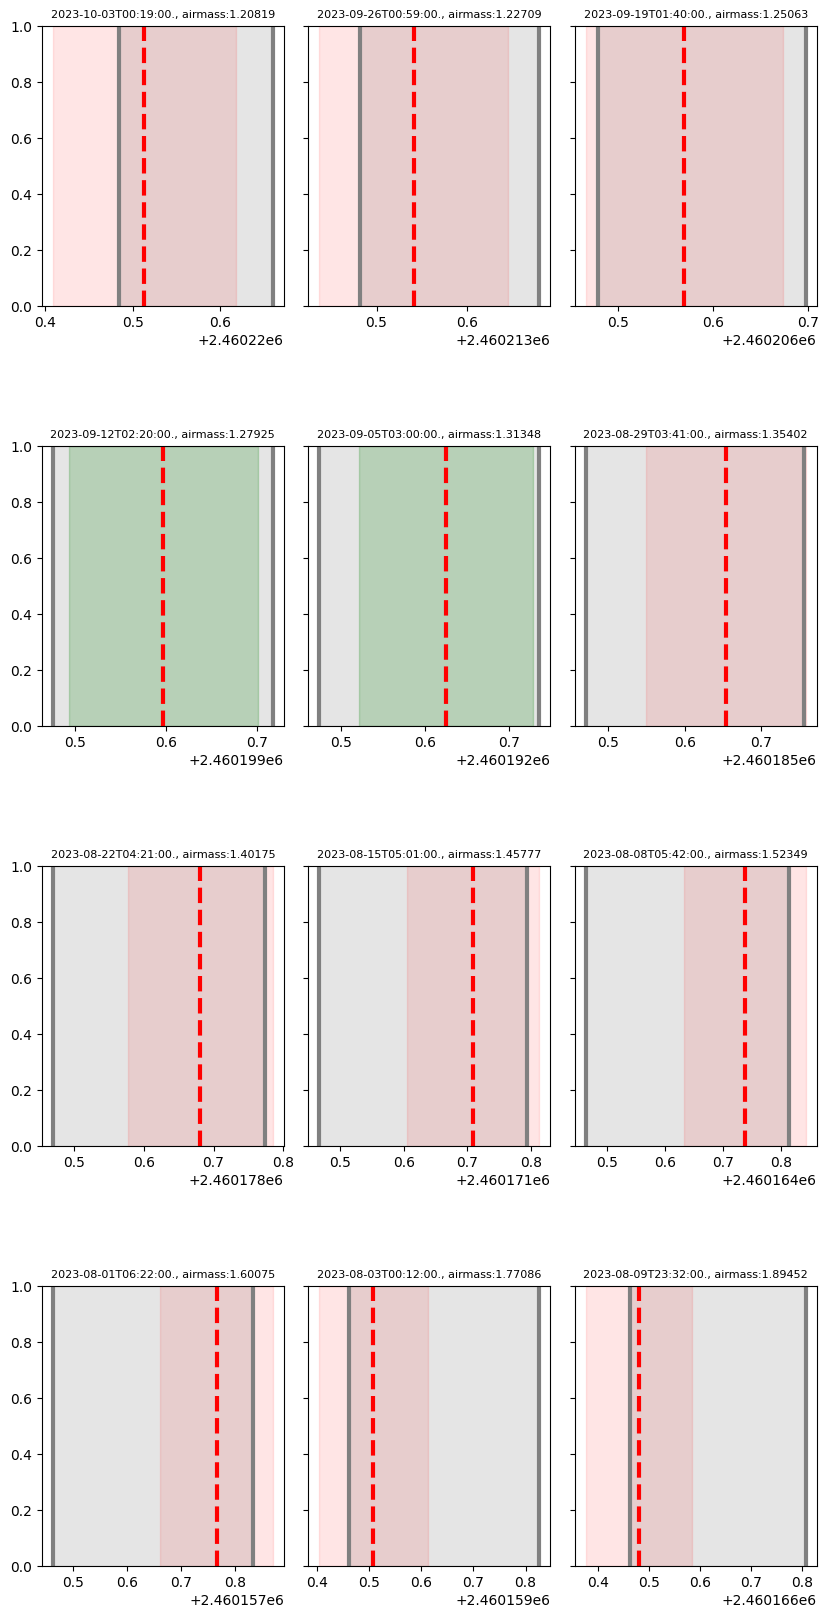

In [12]:
plot_windows(midt, startt, endt, airmass_post, goodness)